Повторяем подготовку данных.

In [5]:
#Импортируем библиотеки
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
%matplotlib inline

from sklearn.cluster import KMeans
from sklearn import preprocessing

import os

#Загружаем данные
data = './Econom_Cities_data.csv'
df = pd.read_csv(data, sep=';', decimal=',',  index_col='City')
df

,Work,Price,Salary
City,,,
Amsterdam,1714,65.6,49.0
Athens,1792,53.8,30.4
Bogota,2152,37.9,11.5
Bombay,2052,30.3,5.3
Brussels,1708,73.8,50.5
Buenos_Aires,1971,56.1,12.5
Cairo,-9999,37.1,-9999.0
Caracas,2041,61.0,10.9
Chicago,1924,73.9,61.9


Стандартизация данных и удаление отрицательных значений.

In [15]:
df['Work'] = round(df['Work']/df.loc['Zurich', 'Work'] * 100, 1)
df = df.drop(['Cairo', 'Jakarta'])
df

,Work,Price,Salary,cluster
City,,,,
Amsterdam,91.8,65.6,49.0,3
Athens,95.9,53.8,30.4,3
Bogota,115.2,37.9,11.5,2
Bombay,109.9,30.3,5.3,2
Brussels,91.4,73.8,50.5,3
Buenos_Aires,105.5,56.1,12.5,1
Caracas,109.3,61.0,10.9,2
Chicago,103.0,73.9,61.9,1
Copenhagen,91.9,91.3,62.9,3


# **Кластеризация методом k - средних**
Определим число кластеров:


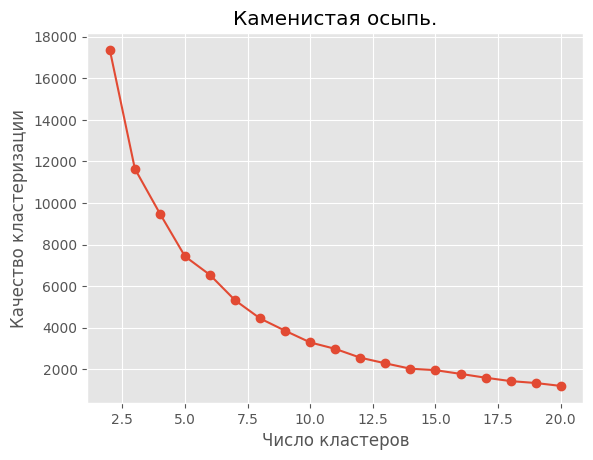

In [16]:
K = range(2, 21)

# Сохраняем модель
models = [KMeans(n_clusters = k, random_state = 42, n_init=10, verbose=0).fit(df) for k in K]

# Качество кластеризации вычисляется в model.inertia_
dist = [model.inertia_ for model in models]

# Строим график каменистая осыпь
plt.plot(K, dist, marker='o')

plt.xlabel('Число кластеров')
plt.ylabel('Качество кластеризации')
plt.title('Каменистая осыпь.')
plt.show()

По графику каменистой осыпи, предположу, что оптимальное количество кластеров 3 или 5. Проверю оба варианта.

# **3 Кластера**

In [18]:
model = KMeans(n_clusters=3, random_state=42, max_iter=300, n_init=10, verbose=0)
model.fit(df)
df['cluster'] = model.labels_
df.groupby('cluster').mean()

,Work,Price,Salary
cluster,,,
0,105.995000,50.800,15.440
1,95.283333,108.550,71.300
2,96.875000,77.865,54.125


In [20]:
df.groupby('cluster').size()

,0
cluster,
0,20
1,6
2,20


# **Вывод**
0) Люди в этих городах много работают, мало зарабатывают, относительно зарплат имеют высокие цены на жизнь.
1) Здесь ниже рабочие часы, высокая цена  и самая высокая зарплата - города с дорогой жизнью и высокими доходами.
2) Здесь почти такие же часы, как в кластере 1, средняя цена  и средняя зарплата - сбалансированные города по соотношению цена-доход.



# **5 Кластеров**

In [21]:
model = KMeans(n_clusters=5, random_state=42, max_iter=300, n_init=10, verbose=0)
model.fit(df)
df['cluster'] = model.labels_
df.groupby('cluster').mean()

,Work,Price,Salary
cluster,,,
0,92.416667,106.750000,58.400000
1,104.870000,57.990000,22.850000
2,97.450000,76.233333,53.866667
3,100.300000,97.950000,95.150000
4,107.120000,43.610000,8.030000


In [23]:
df.groupby('cluster').size()

,0
cluster,
0,6
1,10
2,18
3,2
4,10


# **Вывод**
0) Низкие рабочие часы, очень высокая цена и средняя зарплата - дорогие города со средним доходом.
1) Низкие цены, низкая зарплата, высокие рабочие часы - тяжёлая работа при низких доходах и не высоких ценах.
2) Ниже среднего часы, средняя цена  и средняя зарплата - наиболее сбалансированный, «средний» кластер.
3) Немногочисленный кластер, где повышенные часы, высокая цена  и очень высокая зарплата - элитные, высокодоходные и дорогие города.
4) Самые высокие часы, низкая цена и крайне низкая зарплата - тяжёлый труд за минимальный доход в очень дешёвых городах.